# Notebook 16 — Dissertation Charts

**Project:** MSc AI Dissertation — AI-Generated Text Detection  
**Student:** Abdul Hannaan Mohammed | B00409227 | UWS  
**Purpose:** Generate all 7 figures needed for Chapter 5 (Results)

| Figure | Description | File |
|--------|-------------|------|
| Fig 1 | F1 comparison — clean HC3 | `fig01_clean_f1_comparison.png` |
| Fig 2 | Recall under each attack — all models | `fig02_recall_under_attack.png` |
| Fig 3 | F1 degradation line chart | `fig03_f1_degradation.png` |
| Fig 4 | Recall heatmap | `fig04_recall_heatmap.png` |
| Fig 5 | M4 cross-dataset accuracy | `fig05_m4_generalisation.png` |
| Fig 6 | Human vs RoBERTa detection comparison | `fig06_human_vs_model.png` |
| Fig 7 | RoBERTa confusion matrices (2×2 grid) | `fig07_confusion_matrices.png` |

## Cell 1 — Imports, Paths, and Data

In [18]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')

NOTEBOOK_DIR  = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT  = os.path.dirname(NOTEBOOK_DIR)
RESULTS_FIGS  = os.path.join(PROJECT_ROOT, 'results', 'figures')
os.makedirs(RESULTS_FIGS, exist_ok=True)

DPI = 300
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── ALL DATA HARDCODED FROM VERIFIED RESULTS ────────────────────────────────────
MODELS = ['RoBERTa-base', 'BERT-base', 'DistilBERT', 'Hello-SimpleAI', 'Log. Regression']
MODEL_KEYS = ['RoBERTa-base', 'BERT-base', 'DistilBERT', 'Hello-SimpleAI', 'LogisticRegression']

# Clean HC3
CLEAN_F1       = [0.9913, 0.9845, 0.9922, 0.9929, 0.9524]
CLEAN_RECALL   = [0.9995, 0.9997, 0.9995, 0.9977, 0.9364]
CLEAN_ACCURACY = [0.9942, 0.9895, 0.9948, 0.9953, 0.9689]
CLEAN_PRECISION= [0.9832, 0.9697, 0.9850, 0.9882, 0.9689]
CLEAN_ROCAUC   = [0.9999, 0.9999, 0.9999, 0.9997, 0.9961]

# Attack recall
PEGASUS_RECALL  = [0.0660, 0.8160, 0.7280, 0.0720, 0.7060]
QUILLBOT_RECALL = [0.8660, 0.8780, 0.8100, 0.8600, 0.7320]
CHATGPT_RECALL  = [0.9840, 0.9680, 0.9320, 0.9720, 0.6060]

# Attack success rate = 1 - recall
PEGASUS_ASR  = [round(1-r,4) for r in PEGASUS_RECALL]
QUILLBOT_ASR = [round(1-r,4) for r in QUILLBOT_RECALL]
CHATGPT_ASR  = [round(1-r,4) for r in CHATGPT_RECALL]

# M4 cross-dataset
M4_ACCURACY = [0.7700, 0.7045, 0.6325, 0.6750, 0.5525]
M4_F1       = [0.7389, 0.5999, 0.4316, 0.5442, 0.3356]

# Human evaluation
HUMAN_CONDITIONS  = ['Human Text', 'Original AI', 'Rewritten AI']
HUMAN_ACCURACY    = [0.507, 0.440, 0.307]  # human participants
ROBERTA_DETECTION = [0.991, 0.991, 0.066]  # RoBERTa detection rate (clean recall ≈ human_text)

# RoBERTa confusion matrix data
# Clean (n=11820): TN=7821, FP=67, FN=2, TP=3930
# Attack: n=500 AI-only — FN = (1-recall)*500, TP = recall*500
CM_CLEAN    = np.array([[7821, 67], [2,    3930]])          # TN,FP / FN,TP
CM_PEGASUS  = np.array([[0,    0],  [467,  33  ]])          # AI-only: FN+TP only
CM_QUILLBOT = np.array([[0,    0],  [67,   433 ]])
CM_CHATGPT  = np.array([[0,    0],  [8,    492 ]])

print('Data loaded. Ready to generate 7 dissertation figures.')

Data loaded. Ready to generate 7 dissertation figures.


## Cell 2 — Figure 1: F1 Comparison on Clean HC3 Test Set

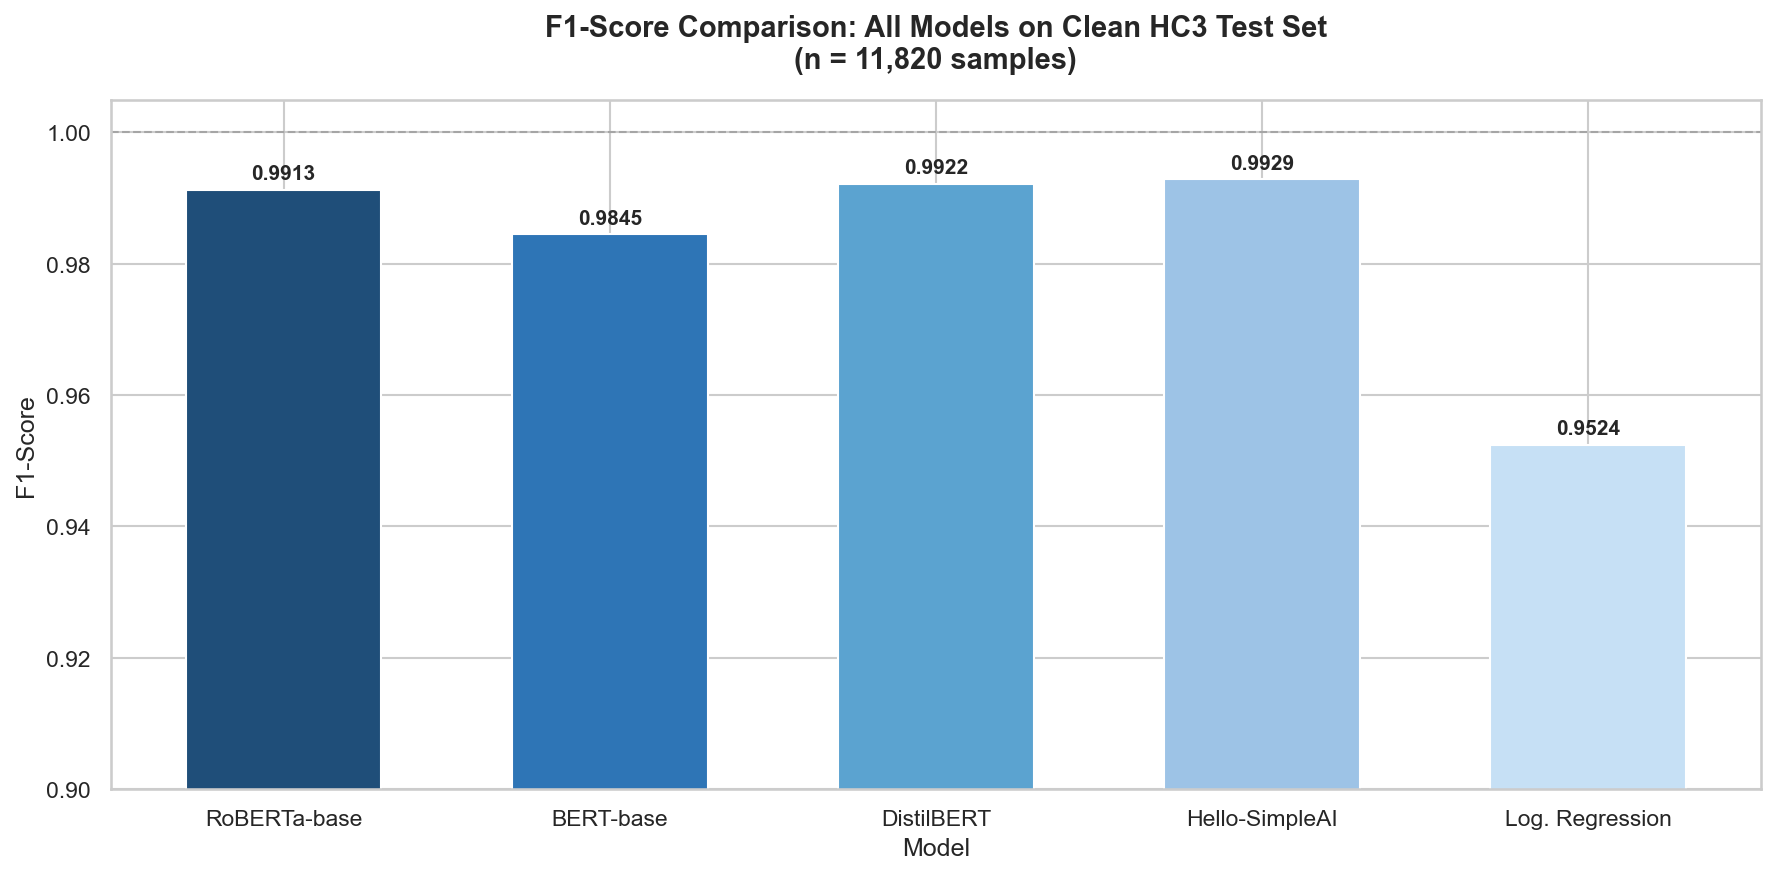

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig01_clean_f1_comparison.png
SCREENSHOT NOW: fig1 for Chapter 5 Figure 1


In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

colours = ['#1f4e79', '#2e75b6', '#5ba3d0', '#9dc3e6', '#c6e0f5']
bars = ax.bar(MODELS, CLEAN_F1, color=colours, edgecolor='white', width=0.6)

ax.set_title('F1-Score Comparison: All Models on Clean HC3 Test Set\n(n = 11,820 samples)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylim(0.90, 1.005)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

for bar, val in zip(bars, CLEAN_F1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
path = os.path.join(RESULTS_FIGS, 'fig01_clean_f1_comparison.png')
plt.savefig(path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')
print('SCREENSHOT NOW: fig1 for Chapter 5 Figure 1')

## Cell 3 — Figure 2: Recall Under Each Attack Condition

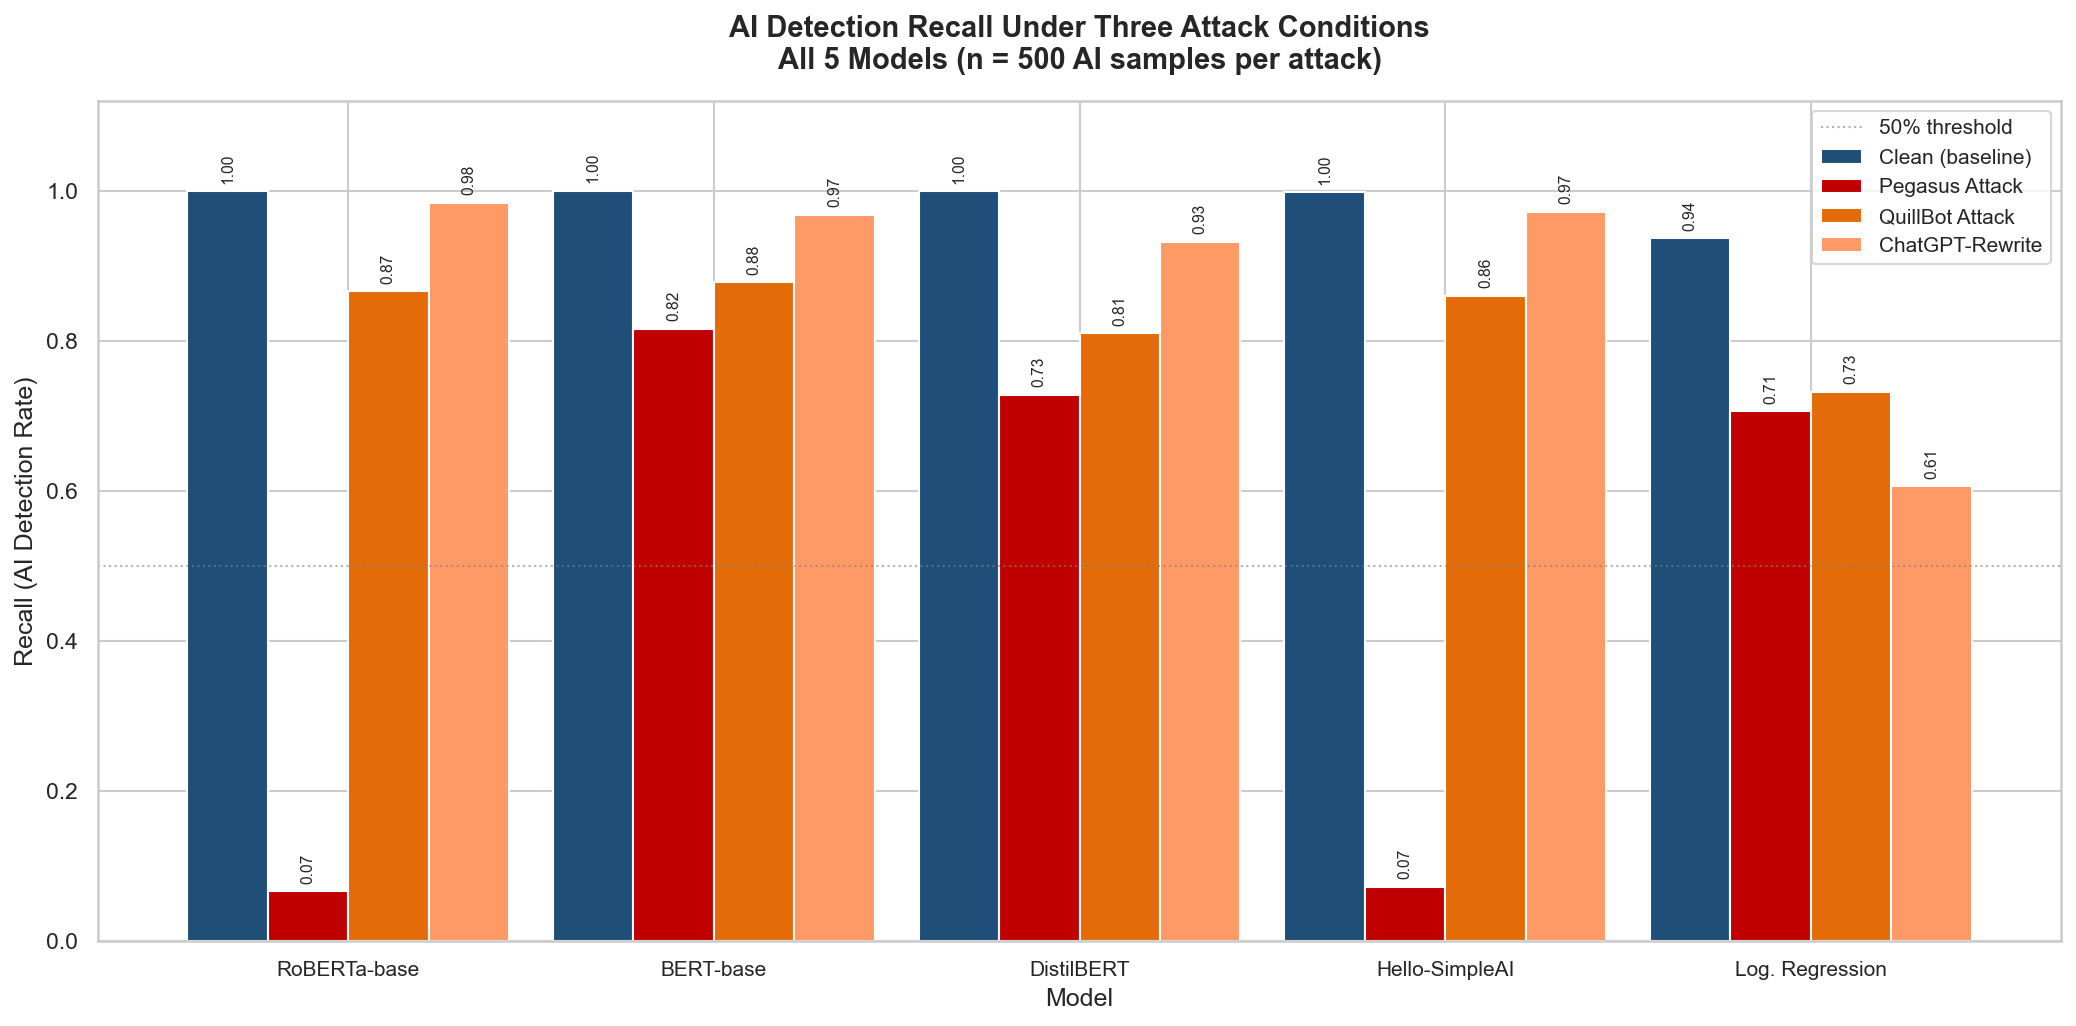

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig02_recall_under_attack.png
SCREENSHOT NOW: fig2 for Chapter 5 Figure 2


In [20]:
x      = np.arange(len(MODELS))
width  = 0.22

fig, ax = plt.subplots(figsize=(14, 7))

b0 = ax.bar(x - width*1.5, CLEAN_RECALL,   width, label='Clean (baseline)',   color='#1f4e79', edgecolor='white')
b1 = ax.bar(x - width*0.5, PEGASUS_RECALL, width, label='Pegasus Attack',     color='#c00000', edgecolor='white')
b2 = ax.bar(x + width*0.5, QUILLBOT_RECALL,width, label='QuillBot Attack',    color='#e36c09', edgecolor='white')
b3 = ax.bar(x + width*1.5, CHATGPT_RECALL, width, label='ChatGPT-Rewrite',    color='#ff9966', edgecolor='white')

ax.set_title('AI Detection Recall Under Three Attack Conditions\nAll 5 Models (n = 500 AI samples per attack)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Recall (AI Detection Rate)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=10)
ax.set_ylim(0, 1.12)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.6, label='50% threshold')
ax.legend(fontsize=10, loc='upper right')

for bars in [b0, b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

plt.tight_layout()
path = os.path.join(RESULTS_FIGS, 'fig02_recall_under_attack.png')
plt.savefig(path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')
print('SCREENSHOT NOW: fig2 for Chapter 5 Figure 2')

## Cell 4 — Figure 3: F1 Degradation Line Chart (Clean → Pegasus Drop)

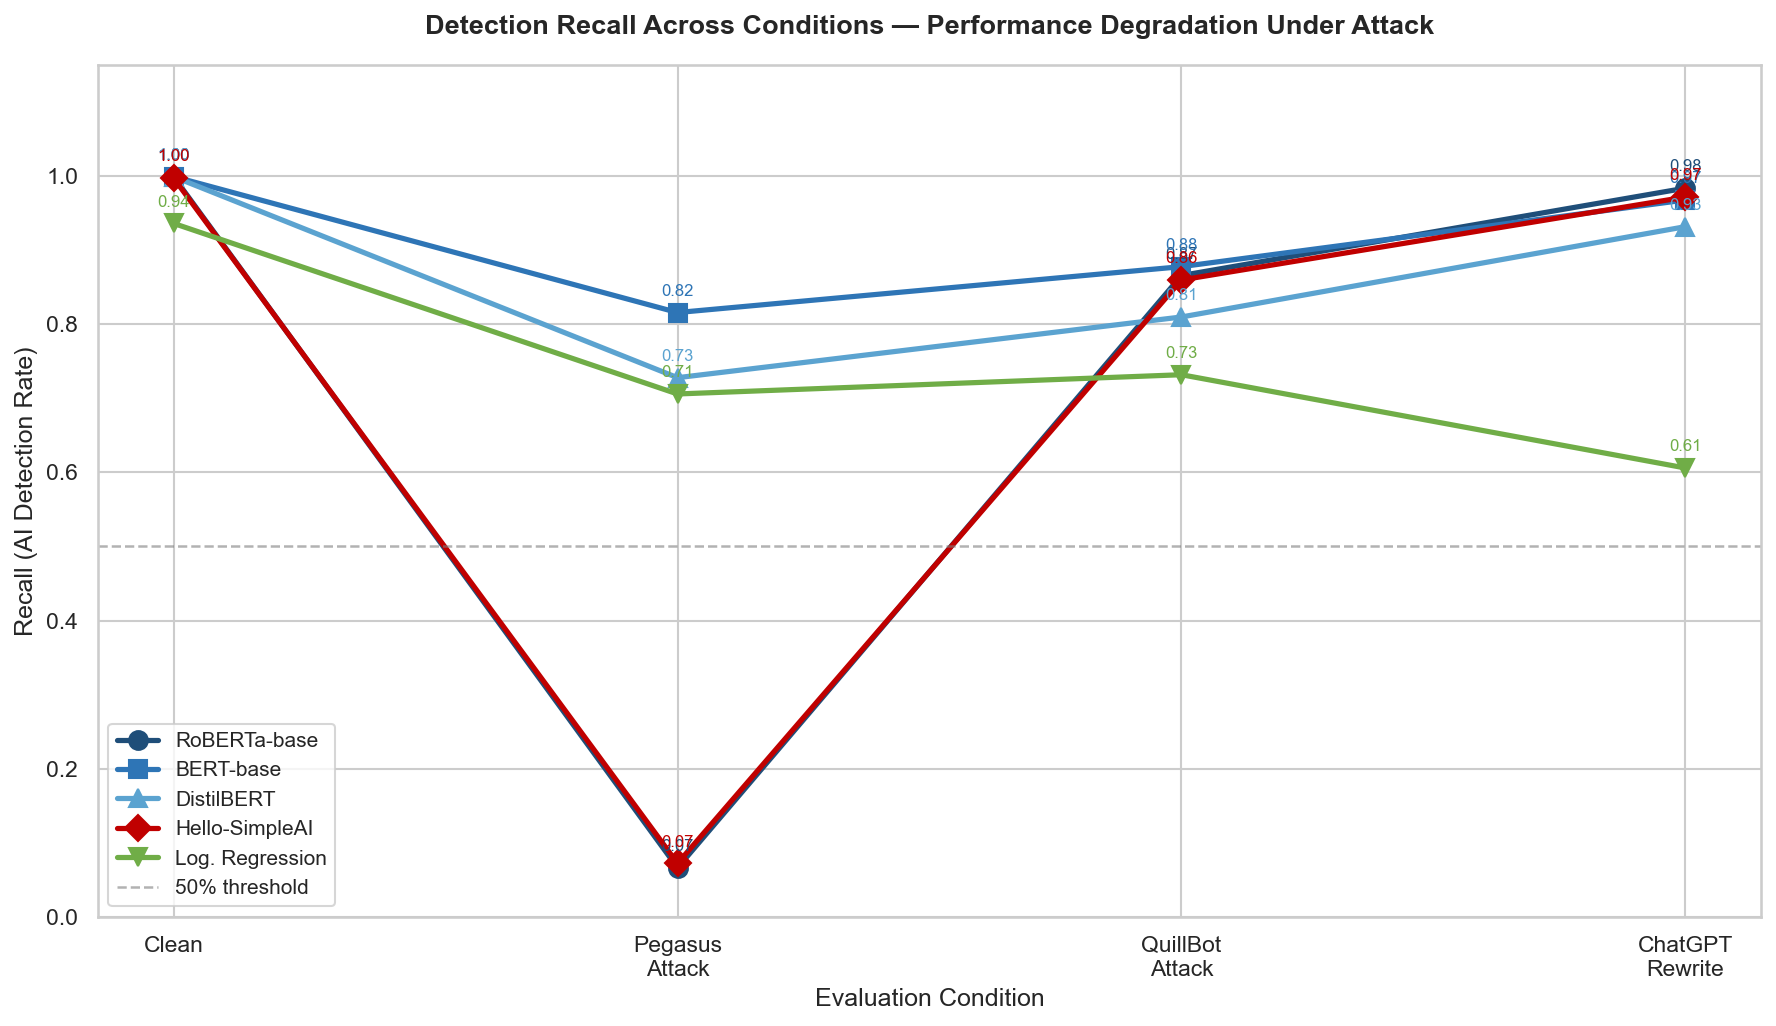

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig03_f1_degradation.png
SCREENSHOT NOW: fig3 for Chapter 5 Figure 3


In [21]:
# Use recall as proxy for F1 trend (attack conditions only stored recall)
conditions     = ['Clean', 'Pegasus\nAttack', 'QuillBot\nAttack', 'ChatGPT\nRewrite']
model_recalls  = {
    'RoBERTa-base'    : [CLEAN_RECALL[0]] + PEGASUS_RECALL[:1] + QUILLBOT_RECALL[:1] + CHATGPT_RECALL[:1],
    'BERT-base'       : [CLEAN_RECALL[1]] + PEGASUS_RECALL[1:2] + QUILLBOT_RECALL[1:2] + CHATGPT_RECALL[1:2],
    'DistilBERT'      : [CLEAN_RECALL[2]] + PEGASUS_RECALL[2:3] + QUILLBOT_RECALL[2:3] + CHATGPT_RECALL[2:3],
    'Hello-SimpleAI'  : [CLEAN_RECALL[3]] + PEGASUS_RECALL[3:4] + QUILLBOT_RECALL[3:4] + CHATGPT_RECALL[3:4],
    'Log. Regression' : [CLEAN_RECALL[4]] + PEGASUS_RECALL[4:5] + QUILLBOT_RECALL[4:5] + CHATGPT_RECALL[4:5],
}

colours_line = ['#1f4e79', '#2e75b6', '#5ba3d0', '#c00000', '#70ad47']
markers      = ['o', 's', '^', 'D', 'v']

fig, ax = plt.subplots(figsize=(12, 7))
x_pos = np.arange(len(conditions))

for i, (model, recalls) in enumerate(model_recalls.items()):
    ax.plot(x_pos, recalls, marker=markers[i], linewidth=2.5, markersize=9,
            color=colours_line[i], label=model)
    for j, val in enumerate(recalls):
        ax.annotate(f'{val:.2f}', (j, val), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color=colours_line[i])

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.6, label='50% threshold')
ax.set_title('Detection Recall Across Conditions — Performance Degradation Under Attack',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=11)
ax.set_ylabel('Recall (AI Detection Rate)', fontsize=12)
ax.set_xlabel('Evaluation Condition', fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10, loc='lower left')

plt.tight_layout()
path = os.path.join(RESULTS_FIGS, 'fig03_f1_degradation.png')
plt.savefig(path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')
print('SCREENSHOT NOW: fig3 for Chapter 5 Figure 3')

## Cell 5 — Figure 4: Recall Heatmap (All Models × All Conditions)

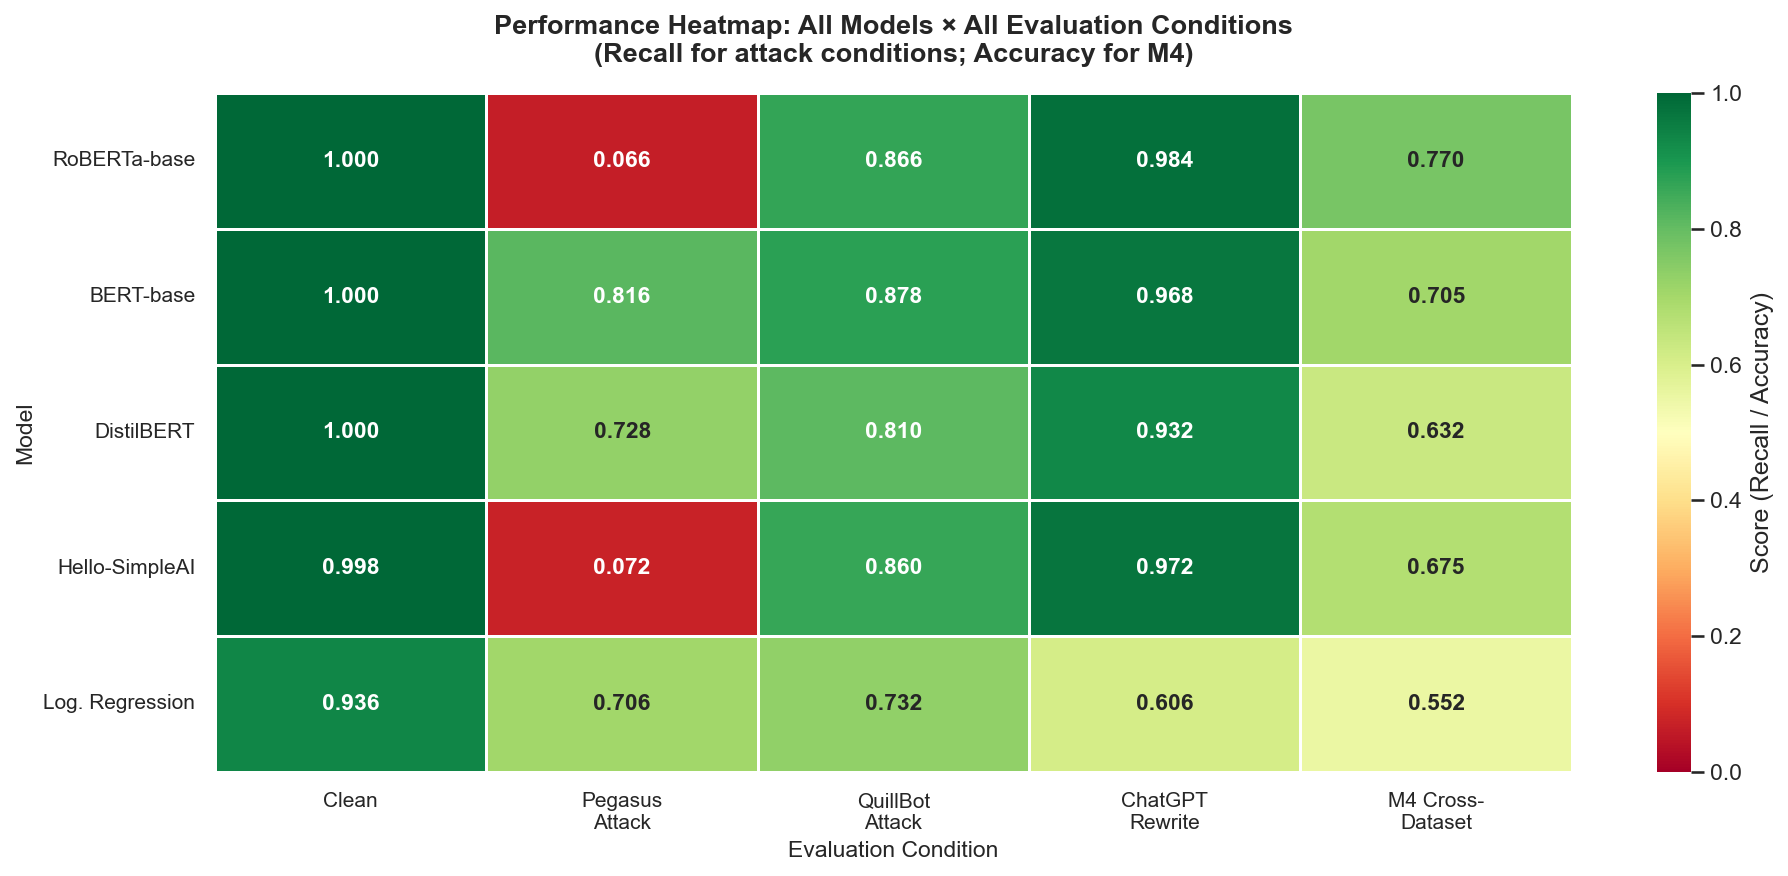

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig04_recall_heatmap.png
SCREENSHOT NOW: fig4 for Chapter 5 Figure 4


In [22]:
heatmap_data = pd.DataFrame({
    'Clean'         : CLEAN_RECALL,
    'Pegasus\nAttack': PEGASUS_RECALL,
    'QuillBot\nAttack':QUILLBOT_RECALL,
    'ChatGPT\nRewrite':CHATGPT_RECALL,
    'M4 Cross-\nDataset': M4_ACCURACY,
}, index=MODELS)

fig, ax = plt.subplots(figsize=(13, 6))

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'}, ax=ax,
            cbar_kws={'label': 'Score (Recall / Accuracy)'})

ax.set_title('Performance Heatmap: All Models × All Evaluation Conditions\n'
             '(Recall for attack conditions; Accuracy for M4)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Evaluation Condition', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10, rotation=0)

plt.tight_layout()
path = os.path.join(RESULTS_FIGS, 'fig04_recall_heatmap.png')
plt.savefig(path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')
print('SCREENSHOT NOW: fig4 for Chapter 5 Figure 4')

## Cell 6 — Figure 5: M4 Cross-Dataset Generalisation

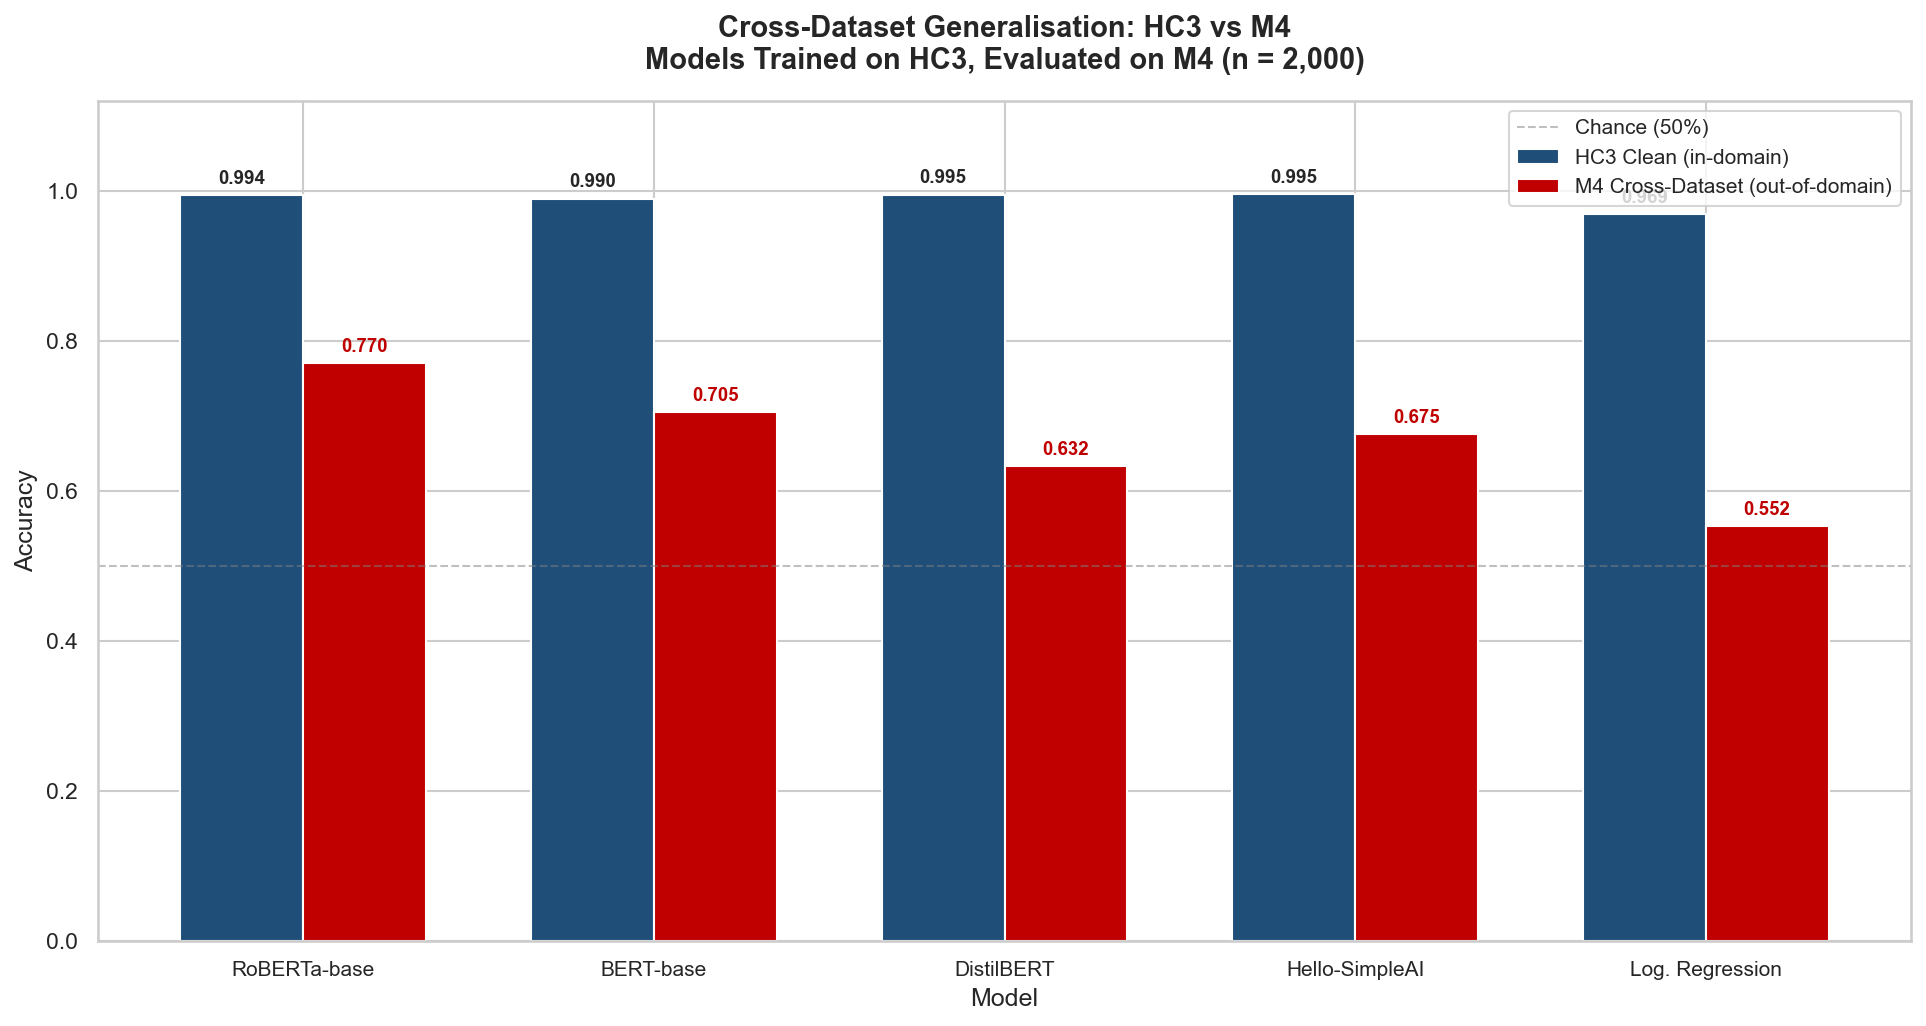

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig05_m4_generalisation.png
SCREENSHOT NOW: fig5 for Chapter 5 Figure 5


In [23]:
x     = np.arange(len(MODELS))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 7))

b1 = ax.bar(x - width/2, CLEAN_ACCURACY, width, label='HC3 Clean (in-domain)',
            color='#1f4e79', edgecolor='white')
b2 = ax.bar(x + width/2, M4_ACCURACY,   width, label='M4 Cross-Dataset (out-of-domain)',
            color='#c00000', edgecolor='white')

ax.set_title('Cross-Dataset Generalisation: HC3 vs M4\nModels Trained on HC3, Evaluated on M4 (n = 2,000)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=10)
ax.set_ylim(0, 1.12)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Chance (50%)')
ax.legend(fontsize=10)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold',
            color='#c00000')

plt.tight_layout()
path = os.path.join(RESULTS_FIGS, 'fig05_m4_generalisation.png')
plt.savefig(path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')
print('SCREENSHOT NOW: fig5 for Chapter 5 Figure 5')

## Cell 7 — Figure 6: Human Evaluation vs RoBERTa Comparison

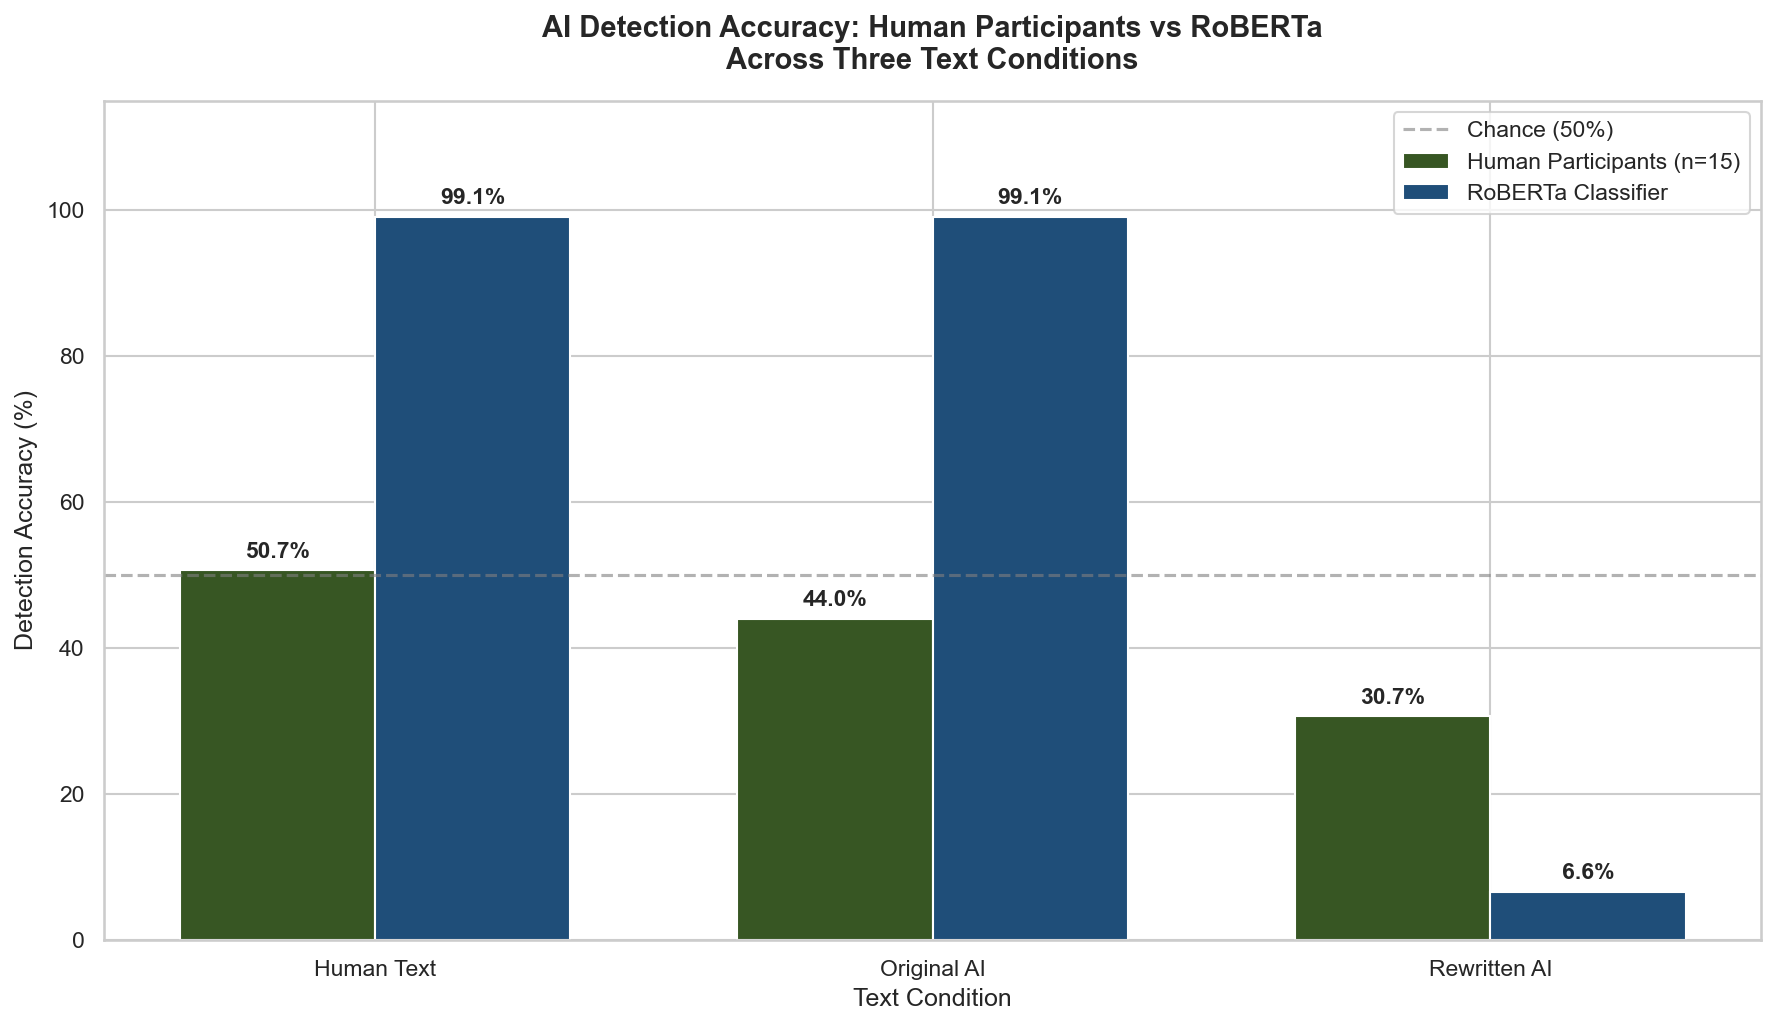

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig06_human_vs_model.png
SCREENSHOT NOW: fig6 for Chapter 5 Figure 6


In [24]:
# Human: 50.7%, 44.0%, 30.7%
# RoBERTa: clean recall ≈ 99.1%, same for human text, 6.6% for pegasus rewritten
x     = np.arange(len(HUMAN_CONDITIONS))
width = 0.35

human_pct   = [v * 100 for v in HUMAN_ACCURACY]
roberta_pct = [v * 100 for v in ROBERTA_DETECTION]

fig, ax = plt.subplots(figsize=(12, 7))

b1 = ax.bar(x - width/2, human_pct,   width, label='Human Participants (n=15)',
            color='#375623', edgecolor='white')
b2 = ax.bar(x + width/2, roberta_pct, width, label='RoBERTa Classifier',
            color='#1f4e79', edgecolor='white')

ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='Chance (50%)')
ax.set_title('AI Detection Accuracy: Human Participants vs RoBERTa\nAcross Three Text Conditions',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Detection Accuracy (%)', fontsize=12)
ax.set_xlabel('Text Condition', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(HUMAN_CONDITIONS, fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)

ax.bar_label(b1, labels=[f'{v:.1f}%' for v in human_pct],   padding=4, fontsize=11, fontweight='bold')
ax.bar_label(b2, labels=[f'{v:.1f}%' for v in roberta_pct], padding=4, fontsize=11, fontweight='bold')

plt.tight_layout()
path = os.path.join(RESULTS_FIGS, 'fig06_human_vs_model.png')
plt.savefig(path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')
print('SCREENSHOT NOW: fig6 for Chapter 5 Figure 6')

## Cell 8 — Figure 7: RoBERTa Confusion Matrices (2×2 Grid)

**Note:** Attack conditions tested on AI-only samples (n=500). Top-left quadrant (TN/FP) is 0 because no human samples were included in the attacked test set — this is the correct experimental design for measuring attack success rate.

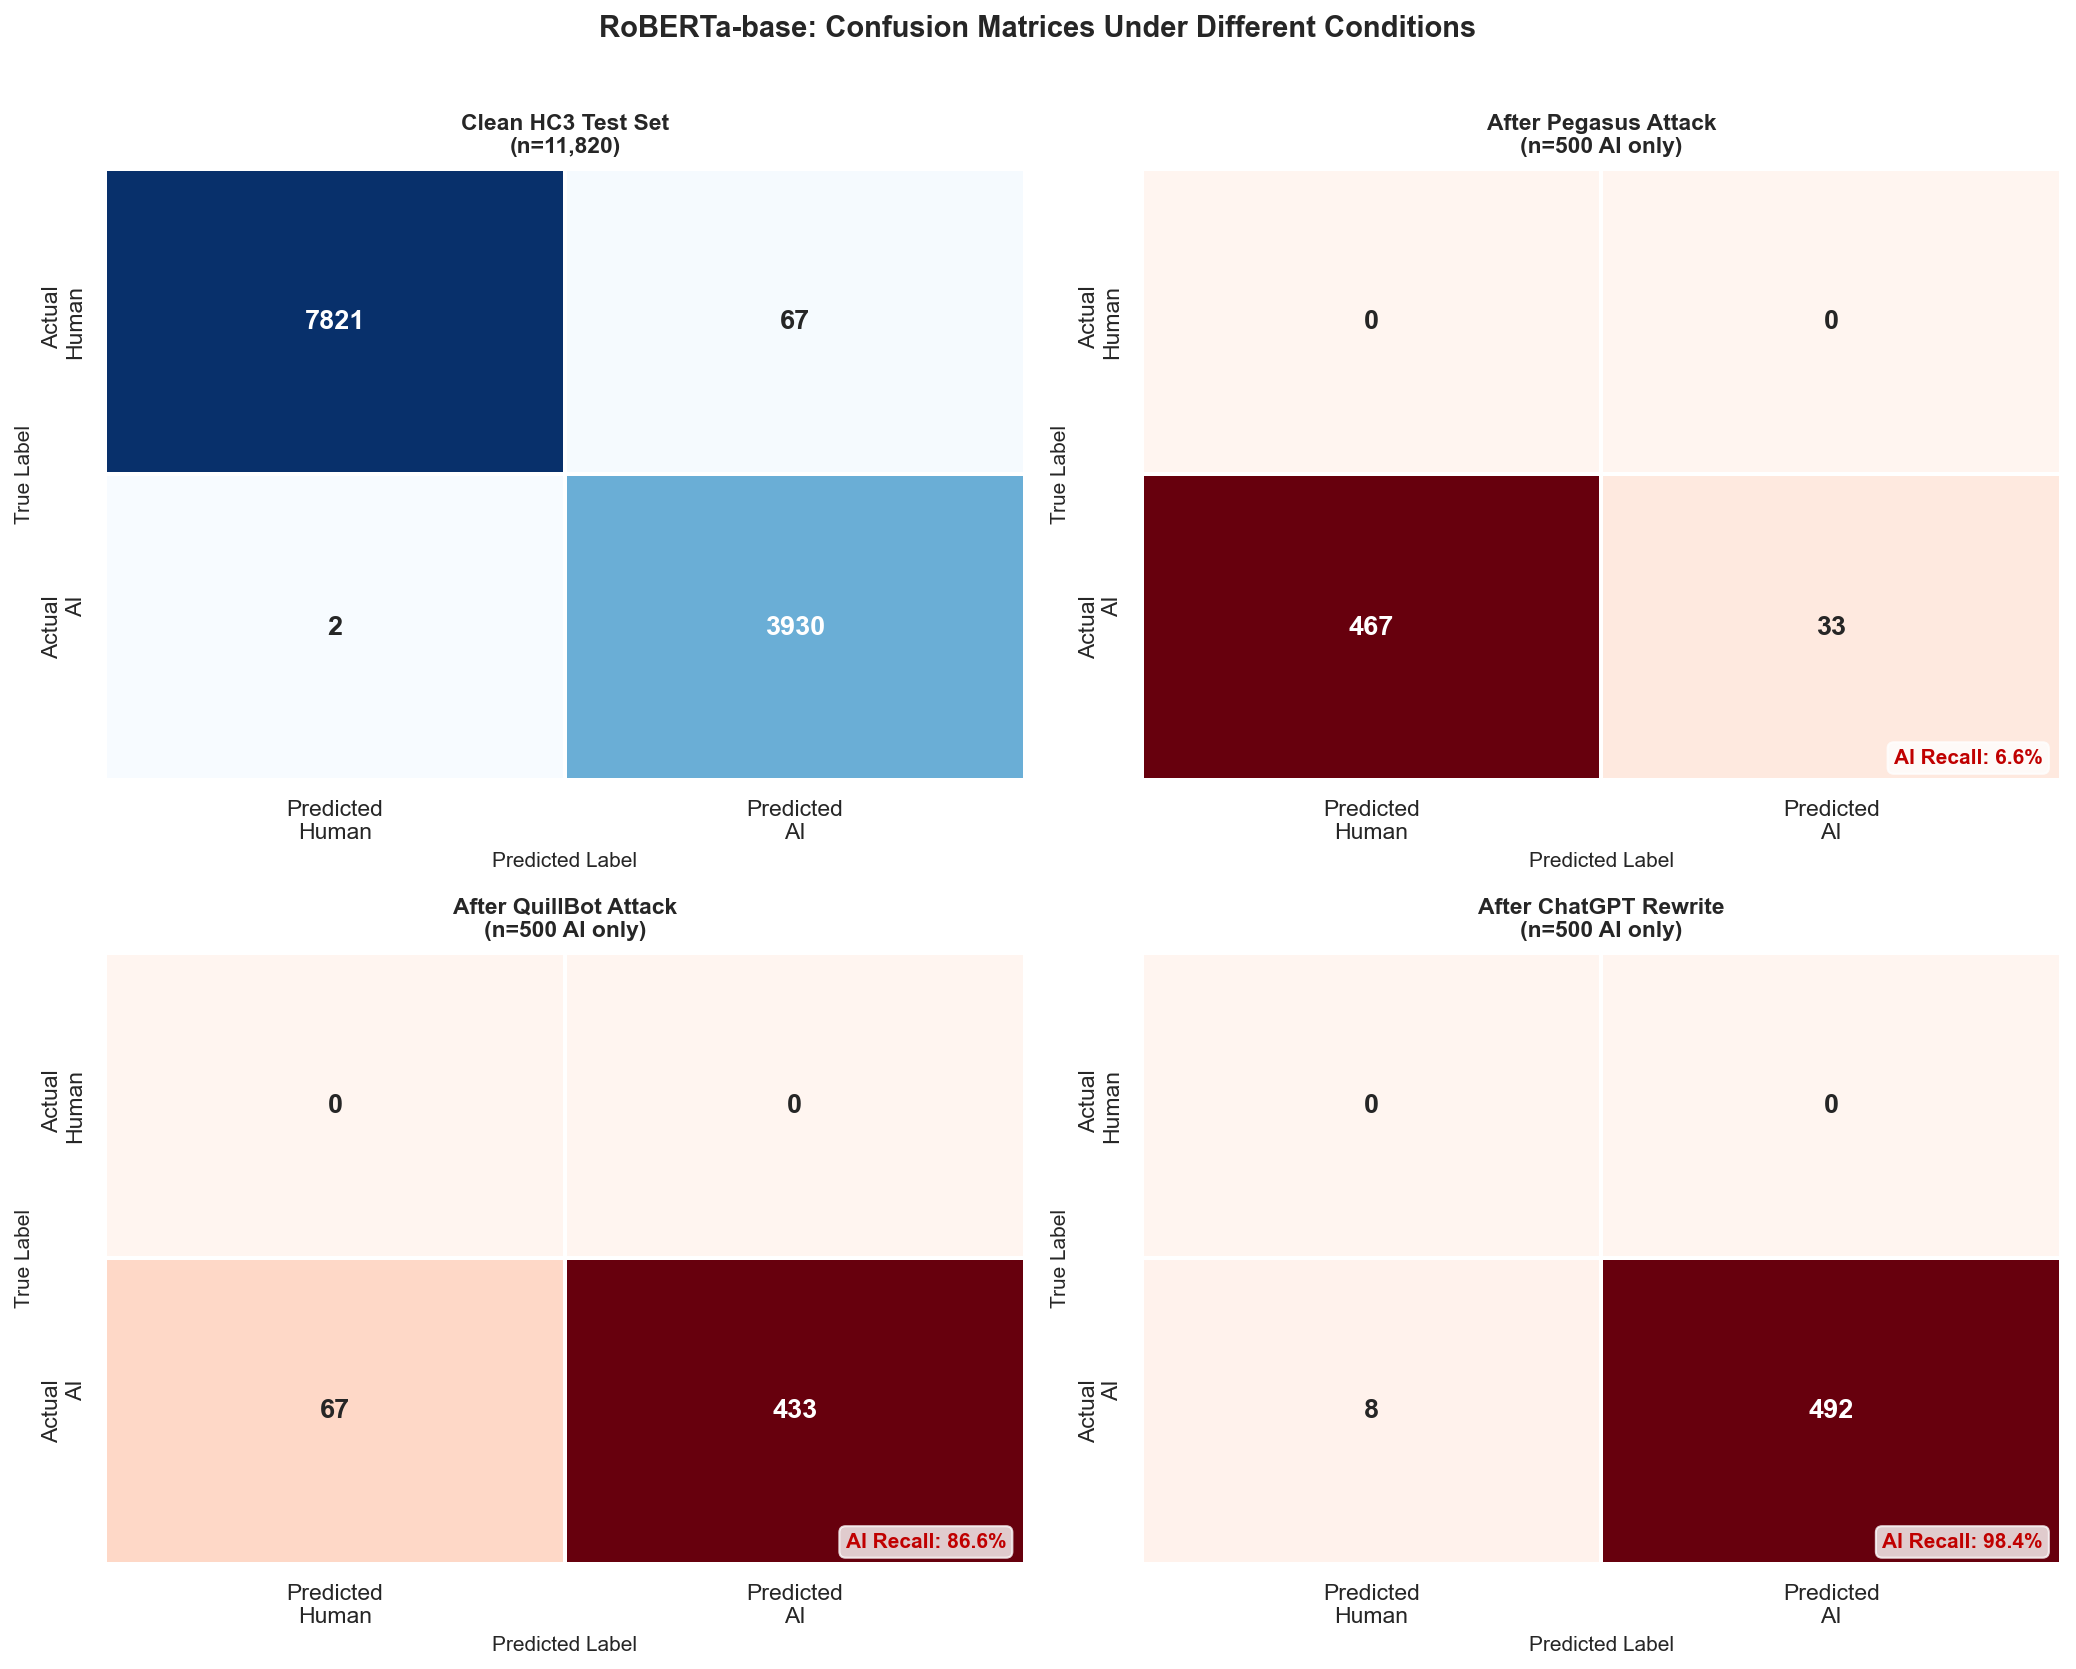

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig07_confusion_matrices.png
SCREENSHOT NOW: fig7 for Chapter 5 Figure 7


In [25]:
titles = [
    'Clean HC3 Test Set\n(n=11,820)',
    'After Pegasus Attack\n(n=500 AI only)',
    'After QuillBot Attack\n(n=500 AI only)',
    'After ChatGPT Rewrite\n(n=500 AI only)',
]
cms = [CM_CLEAN, CM_PEGASUS, CM_QUILLBOT, CM_CHATGPT]
recall_labels = [None, '6.6%', '86.6%', '98.4%']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('RoBERTa-base: Confusion Matrices Under Different Conditions',
             fontsize=14, fontweight='bold', y=1.01)

cmap_clean  = 'Blues'
cmap_attack = 'Reds'

for idx, (ax, cm, title, rl) in enumerate(zip(axes.flat, cms, titles, recall_labels)):
    cmap = cmap_clean if idx == 0 else cmap_attack
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Predicted\nHuman', 'Predicted\nAI'],
                yticklabels=['Actual\nHuman', 'Actual\nAI'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 13, 'weight': 'bold'},
                cbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    if rl:
        ax.text(0.98, 0.02, f'AI Recall: {rl}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=10, fontweight='bold', color='#c00000',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
path = os.path.join(RESULTS_FIGS, 'fig07_confusion_matrices.png')
plt.savefig(path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')
print('SCREENSHOT NOW: fig7 for Chapter 5 Figure 7')

## Cell 9 — Confirm All Files Saved

In [26]:
expected_files = [
    'fig01_clean_f1_comparison.png',
    'fig02_recall_under_attack.png',
    'fig03_f1_degradation.png',
    'fig04_recall_heatmap.png',
    'fig05_m4_generalisation.png',
    'fig06_human_vs_model.png',
    'fig07_confusion_matrices.png',
]

print('=== FILE CHECK ===')
all_ok = True
for fname in expected_files:
    fpath = os.path.join(RESULTS_FIGS, fname)
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) if exists else 0
    status = f'OK ({size//1024} KB)' if exists else 'MISSING'
    print(f'  [{"OK" if exists else "MISSING"}] {fname:45s}  {status}')
    if not exists:
        all_ok = False

print()
if all_ok:
    print('All 7 dissertation figures generated successfully.')
    print()
    print('PUSH TO GITHUB:')
    print('  git add notebooks/15_consolidate_results.ipynb')
    print('  git add notebooks/16_generate_dissertation_charts.ipynb')
    print('  git add results/figures/fig01_clean_f1_comparison.png')
    print('  git add results/figures/fig02_recall_under_attack.png')
    print('  git add results/figures/fig03_f1_degradation.png')
    print('  git add results/figures/fig04_recall_heatmap.png')
    print('  git add results/figures/fig05_m4_generalisation.png')
    print('  git add results/figures/fig06_human_vs_model.png')
    print('  git add results/figures/fig07_confusion_matrices.png')
    print('  git add results/metrics/master_results.csv')
    print('  git commit -m "Week 6: All dissertation figures and master results CSV generated"')
else:
    print('Some files are missing — re-run the cells above.')

=== FILE CHECK ===
  [OK] fig01_clean_f1_comparison.png                  OK (134 KB)
  [OK] fig02_recall_under_attack.png                  OK (207 KB)
  [OK] fig03_f1_degradation.png                       OK (362 KB)
  [OK] fig04_recall_heatmap.png                       OK (250 KB)
  [OK] fig05_m4_generalisation.png                    OK (167 KB)
  [OK] fig06_human_vs_model.png                       OK (164 KB)
  [OK] fig07_confusion_matrices.png                   OK (256 KB)

All 7 dissertation figures generated successfully.

PUSH TO GITHUB:
  git add notebooks/15_consolidate_results.ipynb
  git add notebooks/16_generate_dissertation_charts.ipynb
  git add results/figures/fig01_clean_f1_comparison.png
  git add results/figures/fig02_recall_under_attack.png
  git add results/figures/fig03_f1_degradation.png
  git add results/figures/fig04_recall_heatmap.png
  git add results/figures/fig05_m4_generalisation.png
  git add results/figures/fig06_human_vs_model.png
  git add results/figure

## Notebook 16 Complete

### All 7 dissertation figures produced:

| # | Figure | Used in Dissertation |
|---|--------|---------------------|
| 1 | F1 comparison — clean HC3 | Chapter 5 — Table/Figure reference |
| 2 | Recall under attack — grouped bar | Chapter 5 — main adversarial results |
| 3 | Detection degradation line chart | Chapter 5 — performance trend |
| 4 | Recall heatmap | Chapter 5 — comprehensive overview |
| 5 | M4 cross-dataset accuracy | Chapter 5 — generalisation section |
| 6 | Human vs RoBERTa comparison | Chapter 5 — human evaluation section |
| 7 | Confusion matrices 2×2 | Chapter 5 — RoBERTa detailed analysis |